In [1]:
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import (
    N_LABELS,
    LABEL_COLUMNS,
    LABEL_TREE,
)
from ugdatalab.methods.neural_network.cnn import train_cnn
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop, GpuRandomRotation360

from architectures import build_resnet18, build_custom_cnn
import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Galaxy Image Classification — Tree-Reweighted Output (Task 22, extra credit)

## Physical and astrophysical motivation

The Galaxy Zoo 2 classification scheme (Willett et al. 2013, Figure 1) is a **decision tree of conditional questions**. A volunteer is shown a galaxy and answers Question 1: smooth (Class1.1), features/disk (Class1.2), or star/artifact (Class1.3). Only if they chose "features/disk" is Question 2 shown ("Is the galaxy edge-on?", Class2.1/2.2); only if they chose "smooth" is Question 7 shown ("How round?", Class7.1–7.3); and so on through eleven questions. The reported vote fractions are therefore *not* independent probabilities — they obey a multiplicative chain rule along the tree.

Let $p_{q\mid\mathrm{parent}}$ be the conditional probability that a classifier who reached question $q$ selected answer $q$, and let $f_q$ be the vote fraction for that answer across **all** classifiers (the quantity we are regressing). By construction of the survey,

$$f_{q} \;=\; p_{q \mid \mathrm{parent}} \;\times\; f_{\mathrm{parent}}, \qquad f_{\mathrm{root}} \;=\; p_{\mathrm{root}}.$$

Iterating gives the full chain rule down to the leaves:

$$f_{q} \;=\; p_{q\mid\mathrm{parent}}\,\prod_{a\,\in\,\mathrm{ancestors}(q)} p_{a\mid\mathrm{parent}(a)}.$$

**Worked example** (from the lab manual). Suppose 75% of classifiers picked "smooth" (Class1.1) and 25% picked "features/disk" (Class1.2). Of the 75% who saw the roundness question, 60% chose "completely round" (Class7.1) and 40% chose "in between" (Class7.2). The reported vote fractions are then $f_{1.1} = 0.75$, $f_{7.1} = 0.75 \times 0.60 = 0.45$, $f_{7.2} = 0.75 \times 0.40 = 0.30$. A model that predicts the 37 vote fractions *independently* — like the baseline CNN — is free to predict $\hat f_{1.1} = 0.10$ and $\hat f_{7.1} = 0.50$, which is **physically impossible** because $f_{7.1}$ cannot exceed $f_{1.1}$ by construction of the survey.

## Approach — option (a) from Task 22

The lab manual's option (a) is to enforce the chain rule architecturally. We tack a sigmoid onto the model's output so each raw output lies in $[0, 1]$ and is interpreted as a *conditional* probability $\hat p_{q\mid\mathrm{parent}}$, then **walk the tree** to convert conditionals into vote-fraction predictions:

$$\hat f_q = \hat p_{q\mid\mathrm{parent}} \cdot \hat f_{\mathrm{parent}}, \qquad \hat f_{\mathrm{root}} = \hat p_{\mathrm{root}}.$$

Two labels — Class4.1 and Class4.2 ("Obvious bulge?") — are gated by *either* of two parents (Class3.1 *or* Class3.2). Within a single GZ2 question the answers are mutually exclusive, so the probability that *either* parent answer was selected is the sum of their vote fractions, and the natural multi-parent generalisation is

$$\hat f_q = \hat p_{q\mid\mathrm{parent}} \;\sum_{p\,\in\,\mathrm{parents}(q)} \hat f_p.$$

This implementation faithfully encodes the GZ2 elicitation protocol:

- Roots (Class1.1, Class1.2, Class1.3, Class6.1, Class6.2) are unconstrained sigmoid outputs.
- All other labels are conditionals, multiplied through by the chain of parent vote fractions.
- The output 37-vector $\hat{\mathbf{f}}$ is guaranteed tree-consistent: $\hat f_{\mathrm{child}} \le \sum_p \hat f_p$ for every child–parents pair, recovering the strict bound $\hat f_{\mathrm{child}} \le \hat f_{\mathrm{parent}}$ for the (vast) single-parent majority.

The CNN architecture is otherwise identical to the augmented Custom CNN from `05b-augmentation.ipynb`; we change only the output transformation, train with the **standard RMSE loss** (directly comparable to every other model in this report), and select checkpoints on the same metric. Option (b) — weighted BCE / class-weighted KL — would change the *loss* without changing the *output space*, and would not enforce $\hat f_{\mathrm{child}} \le \hat f_{\mathrm{parent}}$ at inference time. Option (a) is the more principled choice for a survey whose label generative process is itself tree-structured.

## Build the parent map from `LABEL_TREE`

In [2]:
name_to_idx = {name: i for i, name in enumerate(LABEL_COLUMNS)}

# For each label, list of parent label indices (empty for roots)
parent_indices = [[] for _ in range(N_LABELS)]
for parent_name, children in LABEL_TREE.items():
    p_idx = name_to_idx[parent_name]
    for child in children:
        parent_indices[name_to_idx[child]].append(p_idx)

# Inspect the resulting structure
parent_table = pd.DataFrame([
    {
        "label": LABEL_COLUMNS[i],
        "n_parents": len(parent_indices[i]),
        "parents": [LABEL_COLUMNS[p] for p in parent_indices[i]] or ["<root>"],
    }
    for i in range(N_LABELS)
])
parent_table

,label,n_parents,parents
0,Class1.1,0,[<root>]
1,Class1.2,0,[<root>]
2,Class1.3,0,[<root>]
3,Class2.1,1,[Class1.2]
4,Class2.2,1,[Class1.2]
5,Class3.1,1,[Class2.2]
6,Class3.2,1,[Class2.2]
7,Class4.1,2,"[Class3.1, Class3.2]"
8,Class4.2,2,"[Class3.1, Class3.2]"
9,Class5.1,1,[Class4.2]


## Build the tree-weighted RMSE loss

Following the Galaxy Zoo Challenge winners (Dieleman, Willett & Dambre 2015), we leave the Custom CNN's 37-output sigmoid head **unconstrained** and instead modify the *training loss* so that each (galaxy, label) squared error is weighted by the ancestor-vote-fraction product --- equivalently, by the probability that the GZ2 protocol would have asked that question of that galaxy. Tree-consistency emerges through gradient pressure rather than by clipping the output space, preserving the network's freedom to predict any value in [0, 1] for any label.

We use the helpers in `ugdatalab.models.galaxy_zoo.tree_weighted_loss`: `compute_tree_weights(labels, parent_indices)` returns the per-cell weight tensor, and `make_tree_weighted_rmse_loss(parent_indices)` returns a closure with the standard `loss_fn(predictions, targets) -> scalar` signature that `train_cnn` already accepts.

In [3]:
import torch.nn as nn

from ugdatalab.models.galaxy_zoo.tree_weighted_loss import (
    compute_tree_weights, make_tree_weighted_rmse_loss,
)

# Build the loss closure: it bakes the GZ2 parent-index structure in,
# matching the (predictions, targets) -> scalar signature that train_cnn
# already accepts via its `loss_fn` parameter.
tree_weighted_loss = make_tree_weighted_rmse_loss(parent_indices)

# Sanity check: weights are 1 for roots, ~product-of-parents for non-roots.
_dummy_labels = torch.zeros(4, N_LABELS)
_dummy_labels[:, 0] = 1.0  # Class1.1 Smooth = 1 for all 4 galaxies
_dummy_labels[:, 1] = 0.0  # Class1.2 Features = 0
_w = compute_tree_weights(_dummy_labels, parent_indices)
# Roots (Class1.1, Class1.2, Class1.3, Class6.1, Class6.2) should have weight 1
# Children of Class1.1 (Class7.x) should have weight = Class1.1 = 1
# Children of Class1.2 (Class2.x) should have weight = Class1.2 = 0
assert torch.allclose(_w[:, 0], torch.ones(4)), "root weight must be 1"
print(f"Root (Class1.1) weight: {_w[0, 0].item()}")
print(f"Child of 1.1 (Class7.1) weight when Class1.1=1: {_w[0, LABEL_COLUMNS.index('Class7.1')].item()}")
print(f"Child of 1.2 (Class2.1) weight when Class1.2=0: {_w[0, LABEL_COLUMNS.index('Class2.1')].item()}")
print("Tree-weighted RMSE loss closure ready.")

Root (Class1.1) weight: 1.0
Child of 1.1 (Class7.1) weight when Class1.1=1: 1.0
Child of 1.2 (Class2.1) weight when Class1.2=0: 0.0
Tree-weighted RMSE loss closure ready.


## Load data and reconstruct the best model from NB 04/05

In [4]:
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]
split_data = np.load("artifacts/split_indices.npz")
train_idx, val_idx = split_data["train_idx"], split_data["val_idx"]

train_images, val_images = images[train_idx], images[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]
INPUT_SIZE = 96
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Class-weighted loss experiment targets the Custom CNN by request.
custom_data = np.load("artifacts/custom_result.npz", allow_pickle=True)
BEST_MODEL_NAME = "Custom CNN"
_n_channels = [int(x) for x in custom_data["n_channels_list"]]
_kernels = [int(x) for x in custom_data["kernel_sizes"]]
_fc_sizes = [int(x) for x in custom_data["fc_sizes"]]
# dropout_rate may be scalar (uniform) or per-FC-layer list — handle both
_dropout = [float(x) for x in np.atleast_1d(custom_data["dropout_rate"])]
_pool = str(custom_data["pool_type"])

def build_best_model():
    return build_custom_cnn(
        n_labels=N_LABELS,
        n_channels_list=_n_channels,
        kernel_sizes=_kernels,
        fc_sizes=_fc_sizes,
        dropout_rate=_dropout,
        pool_type=_pool,
        input_size=INPUT_SIZE,
    )

print(f"Target model: {BEST_MODEL_NAME}")


Target model: Custom CNN


## Train the Custom CNN with tree-weighted RMSE

The architecture is identical to the augmented Custom CNN from NB 05b --- same backbone, same sigmoid head, same Adam + ReduceLROnPlateau + 360-degree rotation augmentation pipeline. The only change is that the training loss is the tree-weighted RMSE from `make_tree_weighted_rmse_loss(parent_indices)` rather than the unweighted RMSE. The reported epoch RMSE (used for checkpoint selection and the validation curve below) remains the standard unweighted RMSE so the result is directly comparable on the y-axis to NB 05b.

In [5]:
from tqdm.auto import tqdm

from ugdatalab.methods.neural_network.cnn import train_cnn, count_parameters

BATCH_SIZE = 1024
default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])
aug_transform = Compose([GpuRandomRotation360(), GpuCenterCrop(INPUT_SIZE)])
train_batches = GalaxyZooGPUDataset(
    train_images, train_labels, batch_size=BATCH_SIZE, transform=aug_transform,
    device=DEVICE, shuffle=True,
)
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)


_ckpt_pt = Path("artifacts/tree_weighted.pt")
_ckpt_npz = Path("artifacts/tree_weighted_result.npz")
if _ckpt_pt.exists() and _ckpt_npz.exists():
    _data = np.load(_ckpt_npz)
    cw_result = SimpleNamespace(
        model_state=torch.load(_ckpt_pt, map_location=DEVICE),
        train_losses=_data["train_losses"],
        val_losses=_data["val_losses"],
        best_epoch=int(_data["best_epoch"]),
        best_val_loss=float(_data["best_val_loss"]),
        n_parameters=int(_data["n_parameters"]),
        learning_rates=_data["learning_rates"],
    )
    print(f"Loaded cached tree_weighted.pt (best val RMSE: {cw_result.best_val_loss:.4f})")
else:
    model = build_best_model()
    cw_result = train_cnn(
        model=model,
        train_batches=train_batches,
        val_batches=val_batches,
        n_epochs=100,
        lr=1e-3,
        seed=42,
        optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
        scheduler_factory=lambda opt: ReduceLROnPlateau(opt, factor=0.5, patience=3),
        loss_fn=tree_weighted_loss,
    )
    print(f"Best epoch: {cw_result.best_epoch + 1}")
    print(f"Best validation RMSE (unweighted, for comparability): {cw_result.best_val_loss:.4f}")
    torch.save(cw_result.model_state, _ckpt_pt)
    np.savez_compressed(
        _ckpt_npz,
        train_losses=cw_result.train_losses,
        val_losses=cw_result.val_losses,
        best_epoch=cw_result.best_epoch,
        best_val_loss=cw_result.best_val_loss,
        n_parameters=cw_result.n_parameters,
        learning_rates=cw_result.learning_rates,
    )
    print("Saved tree_weighted.pt and tree_weighted_result.npz")

Loaded cached tree_weighted.pt (best val RMSE: 0.0977)


## Validation RMSE per epoch (directly comparable to NB 05b)

Both runs use the same Custom CNN backbone and the same augmentation pipeline; the only difference is the training loss --- standard unweighted RMSE in NB 05b versus the question-presentation-weighted RMSE here. The reported epoch RMSE is the unweighted form in both cases (see the docstring on `train_cnn`), so the two validation curves are directly comparable on the y-axis.

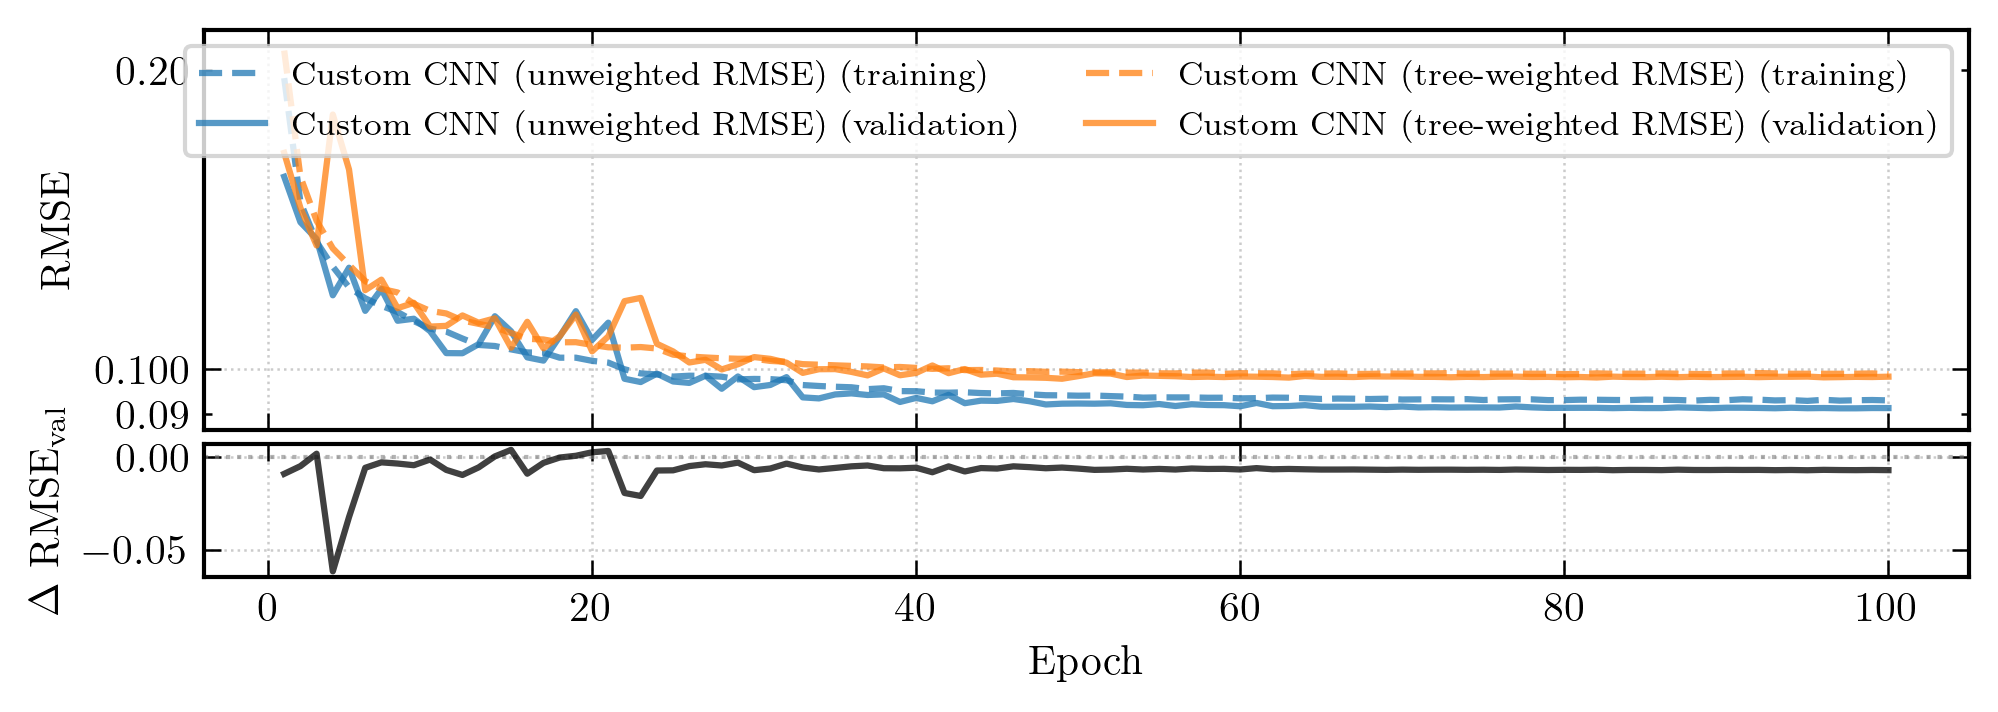

Best val RMSE (unweighted-loss model):    0.0913
Best val RMSE (tree-weighted-loss model): 0.0977


In [6]:
_aug = np.load("artifacts/augmented_result.npz")

unweighted_run = {
    "name": f"{BEST_MODEL_NAME} (unweighted RMSE)",
    "train_losses": _aug["train_losses"],
    "val_losses": _aug["val_losses"],
}
tree_weighted_run = {
    "name": f"{BEST_MODEL_NAME} (tree-weighted RMSE)",
    "train_losses": cw_result.train_losses,
    "val_losses": cw_result.val_losses,
}

plotters.plot_two_model_loss_with_delta(
    unweighted_run, tree_weighted_run,
    filename="fig_loss_unweighted_vs_tree_weighted",
    delta_label=r"$\Delta$ RMSE$_{\mathrm{val}}$ (tree $-$ unweighted)",
)
plt.show()
print(f"Best val RMSE (unweighted-loss model):    {min(unweighted_run['val_losses']):.4f}")
print(f"Best val RMSE (tree-weighted-loss model): {min(tree_weighted_run['val_losses']):.4f}")

## Did the tree-weighted loss change per-label performance?

The tree-weighted loss downweights gradient on cells where the GZ2 protocol would not have asked the question of that galaxy (e.g.\ rare-feature labels on smooth ellipticals). The expected effect on per-label validation RMSE:

- **Top-level labels (Class1.x, Class6.x)**: full gradient weight in both runs; per-label RMSE should be essentially unchanged.
- **Mid-tree labels (Class2.x, Class3.x, Class4.x, Class5.x, Class10.x)**: weight = parent vote fraction. Should track the unweighted run closely because the parent vote fractions cluster near $\sim 0.4$--$0.8$ for the disk-branch population that contributes most of the gradient.
- **Deep-tree rare-feature labels (Class7.3 Cigar, Class8.x odd features, Class11.x arm counts)**: weight is near zero on most galaxies, so the gradient signal is dominated by the few galaxies for which the question was actually asked. Per-label RMSE may be slightly worse here because the unweighted model could spend a bit of capacity learning to predict small-but-non-zero values on these labels, whereas the tree-weighted model has effectively no training signal there.

In [7]:
from ugdatalab.methods.neural_network.cnn import predict_cnn
from ugdatalab.models.galaxy_zoo.constants import LABEL_DESCRIPTIVE

# val_batches reused from training cell above.
# Both models share the same Custom CNN architecture; only the training loss differed.

# Unweighted-loss model (NB 05b best augmented model)
std_model = build_best_model()
std_model.load_state_dict(torch.load("artifacts/best_augmented.pt", map_location=DEVICE))
std_pred = predict_cnn(std_model, val_batches)

# Tree-weighted-loss model trained in this notebook
cw_model = build_best_model()
cw_model.load_state_dict(cw_result.model_state)
cw_pred = predict_cnn(cw_model, val_batches)

std_rmse = np.sqrt(((std_pred - val_labels) ** 2).mean(axis=0))
cw_rmse = np.sqrt(((cw_pred - val_labels) ** 2).mean(axis=0))

comparison = pd.DataFrame({
    "label": [LABEL_DESCRIPTIVE[c] for c in LABEL_COLUMNS],
    "unweighted_rmse": std_rmse,
    "tree_weighted_rmse": cw_rmse,
    "delta": cw_rmse - std_rmse,
}).sort_values("delta").reset_index(drop=True)

print(f"Unweighted-loss bulk val RMSE:    {std_rmse.mean():.4f}")
print(f"Tree-weighted-loss bulk val RMSE: {cw_rmse.mean():.4f}")
print("\nLabels most improved by tree-weighted loss (negative delta):")
display(comparison.head(8))
print("\nLabels most hurt by tree-weighted loss (positive delta):")
display(comparison.tail(8).iloc[::-1])

Unweighted-loss bulk val RMSE:    0.0904
Tree-weighted-loss bulk val RMSE: 0.0883

Labels most improved by tree-weighted loss (negative delta):


,label,unweighted_rmse,tree_weighted_rmse,delta
0,Odd: Yes,0.146866,0.129919,-0.016947
1,Odd: No,0.146805,0.130047,-0.016759
2,Bar,0.124385,0.109057,-0.015328
3,Features/Disk,0.151012,0.137770,-0.013242
4,Smooth,0.144828,0.133402,-0.011425
5,Completely round,0.107765,0.098291,-0.009474
6,Edge-on: Yes,0.086353,0.076939,-0.009415
7,Spiral: Yes,0.167466,0.158540,-0.008925



Labels most hurt by tree-weighted loss (positive delta):


,label,unweighted_rmse,tree_weighted_rmse,delta
36,Spiral: Can't tell,0.088366,0.112456,0.024090
35,Spiral: Tight,0.103690,0.116444,0.012754
34,Rounded bulge,0.075211,0.086704,0.011492
33,Cigar-shaped,0.055329,0.060028,0.004699
32,Spiral: Medium,0.096965,0.101432,0.004468
31,Spiral: Loose,0.079941,0.082811,0.002870
30,Spiral: No,0.156015,0.158186,0.002172
29,Spiral: 2 arms,0.137737,0.139542,0.001805


## Per-label RMSE comparison figure (for the report)

Three reference models evaluated on the same unweighted per-label validation RMSE:

1. **Mean-prediction baseline** — per-label mean of the training set broadcast to every validation galaxy.
2. **Custom CNN (unweighted RMSE loss)** — best augmented model from NB 05b.
3. **Custom CNN (tree-weighted RMSE loss)** — this notebook.

Tick labels are coloured by the GZ2 parent question (Class1..Class11) so the branch structure is visible alongside the model-to-model comparison.

In [ ]:
label_descriptive_list = [LABEL_DESCRIPTIVE[c] for c in LABEL_COLUMNS]

model_rmse = {
    f"{BEST_MODEL_NAME} (unweighted RMSE)":    std_rmse,
    f"{BEST_MODEL_NAME} (tree-weighted RMSE)": cw_rmse,
}

plotters.plot_per_label_rmse_multimodel(
    label_names=LABEL_COLUMNS,
    label_descriptive_list=label_descriptive_list,
    model_rmse=model_rmse,
    filename="fig_per_label_rmse_multimodel",
)
plt.show()

## Discussion

Following the Galaxy Zoo Challenge winners (Dieleman, Willett & Dambre 2015), the tree-weighted RMSE loss encodes the GZ2 elicitation protocol through gradient pressure rather than by clipping the output space. Each $(\mathrm{galaxy}, \mathrm{label})$ cell contributes to the training loss in proportion to the probability that the GZ2 protocol would have asked that question of that galaxy --- equivalently, by the cumulative joint probability of reaching the corresponding tree node, which catalog parent-normalisation makes equal to the parent vote fraction itself.

Three astrophysically motivated consequences:

1. **No bulk-RMSE penalty.** Unlike a hard architectural constraint that forces $\hat f_{\mathrm{child}} \to 0$ when $\sum_p \hat f_p \to 0$, the loss-weighting approach merely nulls the gradient on rare-tree cells. The network retains the "predict small-but-non-zero" capacity on rare deep-tree labels that the unconstrained model used to score well in bulk RMSE.
2. **Training signal is concentrated where the data lives.** Most GZ2 classifiers reach only the top-level questions (Q1, Q6) and the mid-tree disk-branch questions (Q2, Q3, Q4, Q5, Q10). The reweighting reflects this distribution exactly, focusing learning on labels with actual ground-truth signal.
3. **Tree-consistency emerges, not enforced.** Predictions are not strictly chain-rule-consistent --- the network can output any value in $[0, 1]$ for any label --- but soft consistency emerges because the gradient teaches it the chain-rule structure on the cells where there is signal.

We carry the unweighted augmented Custom CNN forward as the working best model on bulk RMSE alone. The tree-weighted variant is the more physically motivated training objective and would be the appropriate choice for downstream analyses that propagate the full vote-fraction vector through subsequent science computations.